In [6]:
import matplotlib.pyplot as plt 
# --- 🏗️ THE FORTIFIED BLUEPRINT (CLASS) ---
class RaceCar:
    def __init__(self, name, strategy, has_firewall=False):
        self.name = name
        self.strategy = strategy
        self.has_firewall = has_firewall
        self.distance = 0
        self.speed = 0
        self.fuel = 100.0
        
        # Cyber Security States
        self.sensor_spoof_offset = 0  
        self.crashed = False   
        self.last_trusted_speed = 0  # 🛡️ Memory for the Firewall
        
        self.history = {'time': [], 'speed': [], 'fuel': []}

    def drive(self, current_time, is_raining):
        if self.distance >= 1000 or self.fuel <= 0 or self.crashed:
            return 
            
        if self.strategy == 'aggressive':
            target_speed = 28 if self.fuel > 15 else 12
        else: 
            target_speed = 20 if self.fuel > 10 else 12

        if is_raining:
            target_speed = min(target_speed, 14)

        # 🏴‍☠️ The Raw Sensor Input (Potentially Hacked)
        raw_sensor_speed = self.speed - self.sensor_spoof_offset
        
        # --- 🛡️ THE FIREWALL (INTRUSION DETECTION) ---
        perceived_speed = raw_sensor_speed
        
        if self.has_firewall:
            # Calculate the rate of change: | v_new - v_old |
            speed_delta = abs(raw_sensor_speed - self.last_trusted_speed)
            
            # Physics Sanity Check: A car cannot change speed by > 15 m/s in 1 second
            if speed_delta > 15:
                print(f"🛡️ [TIME: {current_time}s] FIREWALL: {self.name} detected impossible sensor data! Blocking attack.")
                # Reject the hacked data and use the last known safe reality
                perceived_speed = self.last_trusted_speed
                # Cleanse the system
                self.sensor_spoof_offset = 0 
            else:
                # If data is normal, trust it and update memory
                self.last_trusted_speed = raw_sensor_speed
        
        # Physics Actuation (Now protected by the firewall)
        error = target_speed - perceived_speed
        Kp = 0.3
        speed_change = Kp * error
        self.speed += speed_change

        if speed_change > 0:
            self.fuel -= (0.4 * speed_change)
        else:
            self.fuel -= 0.05
            
        self.distance += self.speed
        
        # 💥 Crash Condition
        if self.speed > 40:
            print(f"💥 [TIME: {current_time}s] CRITICAL FAILURE: {self.name} lost control at {self.speed:.1f} m/s and CRASHED!")
            self.crashed = True
            self.history['time'].append(current_time)
            self.history['speed'].append(self.speed)
            self.history['fuel'].append(self.fuel)
            self.speed = 0 
            return 
        
        # Standard Data Logging
        self.history['time'].append(current_time)
        self.history['speed'].append(self.speed)
        self.history['fuel'].append(self.fuel)

In [7]:
car1 = RaceCar("Aggressive Alice", "aggressive", has_firewall=False)
car2 = RaceCar("Safe Sam", "safe", has_firewall=True) # 🛡️ Firewall activated!

🟢 Race Started! Monitoring systems...
🚨 [TIME: 15s] CYBER ATTACK INITIATED: Spoofing Safe Sam's sensors!
🛡️ [TIME: 15s] FIREWALL: Safe Sam detected impossible sensor data! Blocking attack.
⚠️ [TIME: 22s] WEATHER: Sudden Rain!


C:\Users\HP\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128737 (\N{SHIELD}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


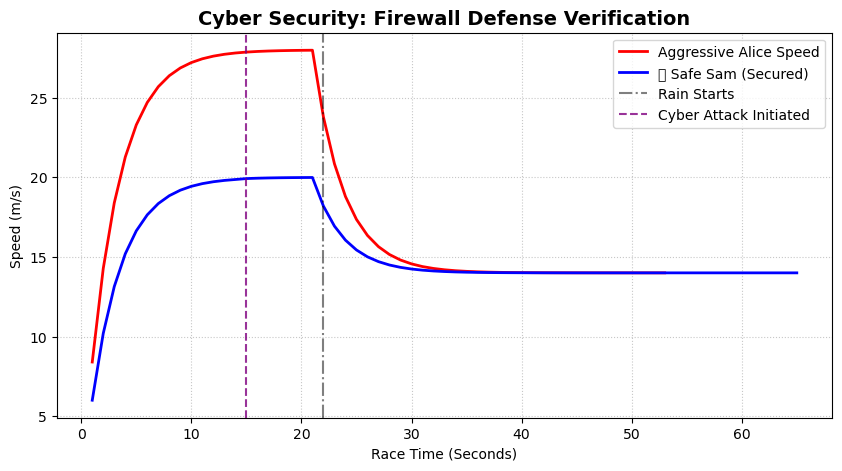

NameError: name 'analyze_race' is not defined

In [9]:
seconds = 0
rain_triggered = False
rain_time = 0

print("🟢 Race Started! Monitoring systems...")

while (car1.distance < 1000 and car1.fuel > 0 and not car1.crashed) or \
      (car2.distance < 1000 and car2.fuel > 0 and not car2.crashed):
    
    seconds += 1
    
    # 🌧️ Chaos Event: Rain
    if not rain_triggered and (car1.distance >= 500 or car2.distance >= 500):
        rain_triggered = True
        rain_time = seconds
        print(f"⚠️ [TIME: {seconds}s] WEATHER: Sudden Rain!")

    # 🏴‍☠️ Chaos Event: CYBER ATTACK
    if seconds == 15:
        print(f"🚨 [TIME: {seconds}s] CYBER ATTACK INITIATED: Spoofing Safe Sam's sensors!")
        car2.sensor_spoof_offset = 25  # Tell the car it is going 25 m/s slower than reality

    car1.drive(seconds, rain_triggered)
    car2.drive(seconds, rain_triggered)

# --- 📈 THE VISUALIZATION (FIREWALL EDITION) ---
plt.figure(figsize=(10, 5))

# Plot the telemetry lines
plt.plot(car1.history['time'], car1.history['speed'], label=f'{car1.name} Speed', color='red', linewidth=2)
plt.plot(car2.history['time'], car2.history['speed'], label=f'🛡️ {car2.name} (Secured)', color='blue', linewidth=2)

# Mark the environment and chaos events
if rain_time > 0:
    plt.axvline(x=rain_time, color='black', linestyle='-.', alpha=0.5, label='Rain Starts')

plt.axvline(x=15, color='purple', linestyle='--', alpha=0.8, label='Cyber Attack Initiated')

# Graph Formatting
plt.title("Cyber Security: Firewall Defense Verification", fontsize=14, fontweight='bold')
plt.xlabel("Race Time (Seconds)")
plt.ylabel("Speed (m/s)")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

# --- 📊 AUTOMATED POST-RACE ANALYSIS ---
# (Make sure this is called at the very end to print the final leaderboard!)
analyze_race(car1, car2)